<a href="https://colab.research.google.com/github/Nishant-2304/LeakSense/blob/main/LeakSense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y numpy scipy wntr
!pip install --no-cache-dir --force-reinstall numpy==2.2.6 scipy==1.15.2 wntr

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: scipy 1.15.2
Uninstalling scipy-1.15.2:
  Successfully uninstalled scipy-1.15.2
Found existing installation: wntr 1.5.0
Uninstalling wntr-1.5.0:
  Successfully uninstalled wntr-1.5.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 67.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 179.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 162.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 182.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 198.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 216.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 219.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 207.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wntr
import os
import shutil
import zipfile
import re
from pathlib import Path
from collections import Counter, defaultdict

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
ZIP_PATH = "/content/drive/MyDrive/Hanoi.zip"

In [7]:
import shutil
from pathlib import Path

partial_path = Path("/content/Hanoi/HanoiOK")

if partial_path.exists():
    shutil.rmtree(partial_path)
    print("Deleted partial extraction:", partial_path)
else:
    print("Folder does not exist.")

Deleted partial extraction: /content/Hanoi/HanoiOK


In [8]:
print("Still exists?", partial_path.exists())

Still exists? False


In [9]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/Hanoi.zip")
extract_path = Path("/content/Hanoi")

extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


In [10]:
import os
from pathlib import Path

DATA_PATH = Path("/content/Hanoi")  # change if your extraction path differs

print("Dataset exists:", DATA_PATH.exists())

if DATA_PATH.exists():
    files = list(DATA_PATH.rglob("*"))
    folders = [f for f in files if f.is_dir()]
    actual_files = [f for f in files if f.is_file()]

    print("Folders:", len(folders))
    print("Files:", len(actual_files))

    print("First 30 files:")
    for f in actual_files[:]:
        print(f)

Dataset exists: True
Folders: 1001
Files: 4510
First 30 files:
/content/Hanoi/HanoiOK/Labels.csv
/content/Hanoi/HanoiOK/Hanoi.inp
/content/Hanoi/HanoiOK/Scenario-493/Hanoi_Scenario-493.inp
/content/Hanoi/HanoiOK/Scenario-493/Node_demands.csv
/content/Hanoi/HanoiOK/Scenario-493/Link_flows.csv
/content/Hanoi/HanoiOK/Scenario-493/Labels.csv
/content/Hanoi/HanoiOK/Scenario-493/Scenario-493_info.csv
/content/Hanoi/HanoiOK/Scenario-493/Node_pressures.csv
/content/Hanoi/HanoiOK/Scenario-201/Scenario-201_info.csv
/content/Hanoi/HanoiOK/Scenario-201/Node_demands.csv
/content/Hanoi/HanoiOK/Scenario-201/Link_flows.csv
/content/Hanoi/HanoiOK/Scenario-201/Labels.csv
/content/Hanoi/HanoiOK/Scenario-201/Node_pressures.csv
/content/Hanoi/HanoiOK/Scenario-201/Hanoi_Scenario-201.inp
/content/Hanoi/HanoiOK/Scenario-495/Scenario-495_info.csv
/content/Hanoi/HanoiOK/Scenario-495/Hanoi_Scenario-495.inp
/content/Hanoi/HanoiOK/Scenario-495/Node_demands.csv
/content/Hanoi/HanoiOK/Scenario-495/Link_flows.csv
/co

In [11]:
from collections import Counter

extensions = Counter(
    f.suffix.lower() if f.suffix else "[no extension]"
    for f in actual_files
)

print("FILE TYPES:")
for ext, count in extensions.most_common():
    print(f"{ext}: {count}")

FILE TYPES:
.csv: 4009
.inp: 501


In [12]:
total_size = sum(f.stat().st_size for f in actual_files)

print(
    f"\nTotal extracted size: "
    f"{total_size / (1024**3):.2f} GB"
)


Total extracted size: 10.36 GB


In [13]:
from pathlib import Path
from collections import defaultdict

BASE = Path("/content/Hanoi/HanoiOK")

csv_types = defaultdict(list)

for csv_file in BASE.rglob("*.csv"):
    csv_types[csv_file.name].append(csv_file)

print("UNIQUE CSV FILE TYPES")
print("=" * 70)

for name, paths in sorted(csv_types.items()):
    print(f"{name:<35} | Count: {len(paths)}")
    print(f"Example: {paths[0]}")
    print()

UNIQUE CSV FILE TYPES
Labels.csv                          | Count: 501
Example: /content/Hanoi/HanoiOK/Labels.csv

Leak_leak_node0_demand.csv          | Count: 499
Example: /content/Hanoi/HanoiOK/Scenario-249/Leaks/Leak_leak_node0_demand.csv

Leak_leak_node0_info.csv            | Count: 499
Example: /content/Hanoi/HanoiOK/Scenario-249/Leaks/Leak_leak_node0_info.csv

Leak_leak_node1_demand.csv          | Count: 255
Example: /content/Hanoi/HanoiOK/Scenario-297/Leaks/Leak_leak_node1_demand.csv

Leak_leak_node1_info.csv            | Count: 255
Example: /content/Hanoi/HanoiOK/Scenario-297/Leaks/Leak_leak_node1_info.csv

Link_flows.csv                      | Count: 500
Example: /content/Hanoi/HanoiOK/Scenario-493/Link_flows.csv

Node_demands.csv                    | Count: 500
Example: /content/Hanoi/HanoiOK/Scenario-493/Node_demands.csv

Node_pressures.csv                  | Count: 500
Example: /content/Hanoi/HanoiOK/Scenario-493/Node_pressures.csv

Scenario-100_info.csv               | Cou

In [14]:
import pandas as pd

print("\nDATASET SCHEMA INSPECTION")

for name, paths in sorted(csv_types.items()):

    file = paths[0]

    print("\n" + "#" * 80)
    print(f"FILE TYPE: {name}")
    print(f"EXAMPLE: {file}")
    print("#" * 80)

    try:
        df = pd.read_csv(file)

        print("Shape:", df.shape)
        print("\nColumns:")
        print(df.columns.tolist())

        print("\nData types:")
        print(df.dtypes)

        print("\nFirst 5 rows:")
        display(df.head())

    except Exception as e:
        print("ERROR READING FILE:", e)


DATASET SCHEMA INSPECTION

################################################################################
FILE TYPE: Labels.csv
EXAMPLE: /content/Hanoi/HanoiOK/Labels.csv
################################################################################
Shape: (500, 2)

Columns:
['Scenario', 'Label']

Data types:
Scenario    int64
Label       int64
dtype: object

First 5 rows:


,Scenario,Label
0,1,0
1,2,2
2,3,1
3,4,1
4,5,2



################################################################################
FILE TYPE: Leak_leak_node0_demand.csv
EXAMPLE: /content/Hanoi/HanoiOK/Scenario-249/Leaks/Leak_leak_node0_demand.csv
################################################################################
Shape: (17520, 2)

Columns:
['Unnamed: 0', 'leak_node0']

Data types:
Unnamed: 0        str
leak_node0    float64
dtype: object

First 5 rows:


,Unnamed: 0,leak_node0
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:30:00,0.0
2,2024-01-01 01:00:00,0.0
3,2024-01-01 01:30:00,0.0
4,2024-01-01 02:00:00,0.0



################################################################################
FILE TYPE: Leak_leak_node0_info.csv
EXAMPLE: /content/Hanoi/HanoiOK/Scenario-249/Leaks/Leak_leak_node0_info.csv
################################################################################
Shape: (6, 2)

Columns:
['Description ', ' Value']

Data types:
Description     str
 Value          str
dtype: object

First 5 rows:


...

,Description,Value
0,Network_Name,Hanoi
1,Duration,8760 hours
2,Time_Step,30.0 min
3,Uncertainty_Topology_(%),NO
4,Uncertainty_Length_(%),10.0



################################################################################
FILE TYPE: Scenario-99_info.csv
EXAMPLE: /content/Hanoi/HanoiOK/Scenario-99/Scenario-99_info.csv
################################################################################
Shape: (7, 2)

Columns:
['Description ', ' Value']

Data types:
Description     str
 Value          str
dtype: object

First 5 rows:


,Description,Value
0,Network_Name,Hanoi
1,Duration,8760 hours
2,Time_Step,30.0 min
3,Uncertainty_Topology_(%),NO
4,Uncertainty_Length_(%),15.000000000000002



################################################################################
FILE TYPE: Scenario-9_info.csv
EXAMPLE: /content/Hanoi/HanoiOK/Scenario-9/Scenario-9_info.csv
################################################################################
Shape: (7, 2)

Columns:
['Description ', ' Value']

Data types:
Description     str
 Value          str
dtype: object

First 5 rows:


,Description,Value
0,Network_Name,Hanoi
1,Duration,8760 hours
2,Time_Step,30.0 min
3,Uncertainty_Topology_(%),NO
4,Uncertainty_Length_(%),10.0


In [15]:
import pandas as pd

def get_summary(file_path):
    """Reads a CSV file and returns its summary (shape, columns, NaNs)."""
    df = pd.read_csv(file_path)
    shape = df.shape
    columns = df.columns.tolist()
    has_nans = df.isnull().any().any()
    return df, shape, columns, has_nans

print("## CSV File Type Summary\n")

# 1. Node_pressures.csv
if 'Node_pressures.csv' in csv_types:
    file = csv_types['Node_pressures.csv'][0]
    df, shape, columns, has_nans = get_summary(file)
    first_column = columns[0]
    rows_are_timestamps = 'Time' in first_column or 'time' in first_column.lower()
    print("Node_pressures:")
    print(f"  Shape: {shape}")
    print(f"  Columns: {columns}")
    print(f"  Rows are: {'timestamps' if rows_are_timestamps else 'nodes (assuming Node IDs)'}")
    print(f"  NaNs: {'yes' if has_nans else 'no'}\n")

# 2. Node_demands.csv
if 'Node_demands.csv' in csv_types:
    file = csv_types['Node_demands.csv'][0]
    df, shape, columns, has_nans = get_summary(file)
    first_column = columns[0]
    rows_are_timestamps = 'Time' in first_column or 'time' in first_column.lower()
    print("Node_demands:")
    print(f"  Shape: {shape}")
    print(f"  Columns: {columns}")
    print(f"  Rows are: {'timestamps' if rows_are_timestamps else 'nodes (assuming Node IDs)'}")
    print(f"  NaNs: {'yes' if has_nans else 'no'}\n")

# 3. Link_flows.csv
if 'Link_flows.csv' in csv_types:
    file = csv_types['Link_flows.csv'][0]
    df, shape, columns, has_nans = get_summary(file)
    first_column = columns[0]
    rows_are_timestamps = 'Time' in first_column or 'time' in first_column.lower()
    print("Link_flows:")
    print(f"  Shape: {shape}")
    print(f"  Columns: {columns}")
    print(f"  Rows are: {'timestamps' if rows_are_timestamps else 'links (assuming Link IDs)'}")
    print(f"  NaNs: {'yes' if has_nans else 'no'}\n")

# 4. Labels.csv
if 'Labels.csv' in csv_types:
    file = csv_types['Labels.csv'][0]
    df, shape, columns, has_nans = get_summary(file)
    print("Labels:")
    print(f"  Shape: {shape}")
    print(f"  Columns: {columns}")
    print(f"  Contains leak node ID: {'Leak_Node_ID' in columns}")
    print(f"  Contains leak x/y: {'Leak_X' in columns and 'Leak_Y' in columns}")
    print(f"  Contains Q_L: {'Q_L' in columns or 'Leak_Q_L' in columns}")
    print(f"  NaNs: {'yes' if has_nans else 'no'}\n")

# 5. Scenario-X_info.csv (taking the first one as representative)
scenario_info_keys = [k for k in csv_types if k.startswith('Scenario-') and k.endswith('_info.csv')]
if scenario_info_keys:
    # Take the first one as representative
    file = csv_types[scenario_info_keys[0]][0]
    df, shape, columns, has_nans = get_summary(file)
    print(f"Scenario-X_info.csv (example: {scenario_info_keys[0].split('/')[-1]}):")
    print(f"  Shape: {shape}")
    print(f"  Columns: {columns}")
    print(f"  Example values (first row):\n{df.iloc[0].to_dict()}")
    print(f"  NaNs: {'yes' if has_nans else 'no'}\n")

# 6. Any other CSV type
processed_types = ['Node_pressures.csv', 'Node_demands.csv', 'Link_flows.csv', 'Labels.csv'] + scenario_info_keys
other_csv_types = [k for k in csv_types if k not in processed_types]

if other_csv_types:
    print("Other CSV Types:")
    for name in other_csv_types:
        file = csv_types[name][0]
        df, shape, columns, has_nans = get_summary(file)
        print(f"  {name}:")
        print(f"    Shape: {shape}")
        print(f"    Columns: {columns}")
        print(f"    NaNs: {'yes' if has_nans else 'no'}\n")

## CSV File Type Summary

Node_pressures:
  Shape: (17520, 35)
  Columns: ['Unnamed: 0', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', 'leak_node0', 'leak_node1', '1']
  Rows are: nodes (assuming Node IDs)
  NaNs: no

Node_demands:
  Shape: (17520, 35)
  Columns: ['Unnamed: 0', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', 'leak_node0', 'leak_node1', '1']
  Rows are: nodes (assuming Node IDs)
  NaNs: no

Link_flows:
  Shape: (17520, 37)
  Columns: ['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '9l', '34l']
  Rows are: links (assuming Link IDs)
  NaNs: no

Labels:
  S

In [16]:
info = pd.read_csv(
    "/content/Hanoi/HanoiOK/Scenario-95/Scenario-95_info.csv"
)

display(info)

,Description,Value
0,Network_Name,Hanoi
1,Duration,8760 hours
2,Time_Step,30.0 min
3,Uncertainty_Topology_(%),NO
4,Uncertainty_Length_(%),10.0
5,Uncertainty_Diameter_(%),10.0
6,Uncertainty_Roughness_(%),10.0


In [17]:
labels = pd.read_csv(
    "/content/Hanoi/HanoiOK/Scenario-95/Labels.csv"
)

print(labels.head(10))
print(labels.tail(10))
print(labels["Label"].unique()[:20])

             Timestamp  Label
0  2024-01-01 00:00:00    0.0
1  2024-01-01 00:30:00    0.0
2  2024-01-01 01:00:00    0.0
3  2024-01-01 01:30:00    0.0
4  2024-01-01 02:00:00    0.0
5  2024-01-01 02:30:00    0.0
6  2024-01-01 03:00:00    0.0
7  2024-01-01 03:30:00    0.0
8  2024-01-01 04:00:00    0.0
9  2024-01-01 04:30:00    0.0
                 Timestamp  Label
17510  2024-12-30 19:00:00    0.0
17511  2024-12-30 19:30:00    0.0
17512  2024-12-30 20:00:00    0.0
17513  2024-12-30 20:30:00    0.0
17514  2024-12-30 21:00:00    0.0
17515  2024-12-30 21:30:00    0.0
17516  2024-12-30 22:00:00    0.0
17517  2024-12-30 22:30:00    0.0
17518  2024-12-30 23:00:00    0.0
17519  2024-12-30 23:30:00    0.0
[0. 1.]


In [18]:
"""start = next(i for i, line in enumerate(lines)
             if line.strip().upper() == "[JUNCTIONS]")

end = next(i for i in range(start + 1, len(lines))
           if lines[i].startswith("[") and i != start)

junction_lines = [
    line for line in lines[start+1:end]
    if line.strip() and not line.strip().startswith(";")
]

print("Number of junctions:", len(junction_lines))
print("\n".join(junction_lines))"""

'start = next(i for i, line in enumerate(lines)\n             if line.strip().upper() == "[JUNCTIONS]")\n\nend = next(i for i in range(start + 1, len(lines))\n           if lines[i].startswith("[") and i != start)\n\njunction_lines = [\n    line for line in lines[start+1:end]\n    if line.strip() and not line.strip().startswith(";")\n]\n\nprint("Number of junctions:", len(junction_lines))\nprint("\n".join(junction_lines))'

In [19]:
from pathlib import Path
import pandas as pd

SCENARIO = Path("/content/Hanoi/HanoiOK/Scenario-95")
LEAKS = SCENARIO / "Leaks"

print("Leaks folder exists:", LEAKS.exists())
print("\nFiles:")
for f in sorted(LEAKS.glob("*.csv")):
    print("-", f.name)

Leaks folder exists: True

Files:
- Leak_leak_node0_demand.csv
- Leak_leak_node0_info.csv


In [20]:
info_files = sorted(LEAKS.glob("*_info.csv"))

for f in info_files:
    print("\n" + "="*70)
    print(f.name)
    print("="*70)

    df = pd.read_csv(f)
    display(df)


Leak_leak_node0_info.csv


,Description,Value
0,Leak Node,leak_node0
1,Leak Area,0.0006267084407466471
2,Leak Diameter,0.02824802017448337
3,Leak Type,small
4,Leak Start,2024-04-16 19:30:00
5,Leak End,2024-07-26 14:00:00


In [21]:
demand_files = sorted(LEAKS.glob("*_demand.csv"))

for f in demand_files:
    print("\n" + "="*70)
    print(f.name)
    print("="*70)

    df = pd.read_csv(f)

    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())

    print("\nStats:")
    display(df.describe())


Leak_leak_node0_demand.csv
Shape: (17520, 2)
Columns: ['Unnamed: 0', 'leak_node0']


,Unnamed: 0,leak_node0
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:30:00,0.0
2,2024-01-01 01:00:00,0.0
3,2024-01-01 01:30:00,0.0
4,2024-01-01 02:00:00,0.0



Stats:


,leak_node0
count,17520.000000
mean,4.668822
std,7.560859
min,0.000000
25%,0.000000
50%,0.000000
75%,16.507730
max,17.384920


In [22]:
inp_path = "/content/Hanoi/HanoiOK/Scenario-95/Hanoi_Scenario-95.inp"

with open(inp_path, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "leak_node0" in line:
        print(f"Line {i}: {line.rstrip()}")

Line 38:  leak_node0                        30               0                            ;
Line 80:  32                   30                   leak_node0              88.768003269    294.13197876    131.54449265               0                 Open   ;
Line 83:  32l                  leak_node0           31                       73.22641852    294.13197876    131.54449265               0                 Open   ;
Line 90755: leak_node0       2716.120000000       7499.545990007


In [23]:
import re
import pandas as pd
from pathlib import Path

BASE = Path("/content/Hanoi/HanoiOK")

records = []

# ---------- helper: extract coordinates from .inp ----------
def get_coordinates(inp_path):
    coords = {}
    in_coordinates = False

    with open(inp_path, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if line.upper() == "[COORDINATES]":
                in_coordinates = True
                continue

            # Stop when next EPANET section begins
            if in_coordinates and line.startswith("["):
                break

            if not in_coordinates or not line or line.startswith(";"):
                continue

            parts = line.split()

            if len(parts) >= 3:
                try:
                    node_id = parts[0]
                    x = float(parts[1])
                    y = float(parts[2])

                    coords[node_id] = (x, y)
                except ValueError:
                    pass

    return coords


# ---------- loop through scenarios ----------
scenario_dirs = sorted(
    [p for p in BASE.glob("Scenario-*") if p.is_dir()],
    key=lambda p: int(p.name.split("-")[1])
)

print(f"Found {len(scenario_dirs)} scenarios")

for scenario_dir in scenario_dirs:

    scenario_id = int(scenario_dir.name.split("-")[1])

    # Scenario-specific network file
    inp_path = scenario_dir / f"Hanoi_Scenario-{scenario_id}.inp"

    if not inp_path.exists():
        print(f"WARNING: Missing INP for Scenario {scenario_id}")
        continue

    # Extract all node coordinates
    coordinates = get_coordinates(inp_path)

    # Leak files
    leaks_dir = scenario_dir / "Leaks"

    if not leaks_dir.exists():
        print(f"WARNING: No Leaks folder for Scenario {scenario_id}")
        continue

    info_files = sorted(leaks_dir.glob("Leak_*_info.csv"))

    for info_file in info_files:

        # Read leak metadata
        info_df = pd.read_csv(info_file)

        # Convert Description -> Value into dictionary
        info_dict = dict(
            zip(
                info_df.iloc[:, 0].astype(str).str.strip(),
                info_df.iloc[:, 1]
            )
        )

        leak_id = str(info_dict.get("Leak Node", "")).strip()

        if not leak_id:
            print(f"WARNING: Could not find Leak Node in {info_file}")
            continue

        # Exact coordinates of artificial leak node
        x0, y0 = coordinates.get(leak_id, (None, None))

        # Matching demand file
        demand_file = leaks_dir / f"Leak_{leak_id}_demand.csv"

        records.append({
            "scenario": scenario_id,
            "leak_id": leak_id,
            "x0": x0,
            "y0": y0,
            "leak_area": info_dict.get("Leak Area"),
            "leak_diameter": info_dict.get("Leak Diameter"),
            "leak_type": info_dict.get("Leak Type"),
            "leak_start": info_dict.get("Leak Start"),
            "leak_end": info_dict.get("Leak End"),
            "demand_file": str(demand_file),
            "coordinates_found": x0 is not None and y0 is not None
        })


# ---------- final metadata table ----------
leak_metadata = pd.DataFrame(records)

# Convert types
for col in ["x0", "y0", "leak_area", "leak_diameter"]:
    leak_metadata[col] = pd.to_numeric(
        leak_metadata[col],
        errors="coerce"
    )

leak_metadata["leak_start"] = pd.to_datetime(
    leak_metadata["leak_start"],
    errors="coerce"
)

leak_metadata["leak_end"] = pd.to_datetime(
    leak_metadata["leak_end"],
    errors="coerce"
)

print("\n" + "=" * 80)
print("LEAK METADATA EXTRACTION COMPLETE")
print("=" * 80)

print(f"Total leak records: {len(leak_metadata)}")
print(f"Unique scenarios: {leak_metadata['scenario'].nunique()}")
print(f"Missing coordinates: {leak_metadata['coordinates_found'].eq(False).sum()}")
print()

display(leak_metadata.head(10))

print("\nLeak type distribution:")
print(leak_metadata["leak_type"].value_counts())

print("\nLeaks per scenario:")
print(leak_metadata.groupby("scenario").size().value_counts().sort_index())

Found 500 scenarios

LEAK METADATA EXTRACTION COMPLETE
Total leak records: 754
Unique scenarios: 499
Missing coordinates: 0



,scenario,leak_id,x0,y0,leak_area,leak_diameter,leak_type,leak_start,leak_end,demand_file,coordinates_found
0,2,leak_node0,7260.510000,7231.791224,0.001405,0.042294,small,2024-04-24 23:00:00,2024-05-05 11:30:00,/content/Hanoi/HanoiOK/Scenario-2/Leaks/Leak_l...,True
1,2,leak_node1,6793.220000,8088.173703,0.076565,0.312227,big,2024-08-08 22:00:00,2024-09-16 16:30:00,/content/Hanoi/HanoiOK/Scenario-2/Leaks/Leak_l...,True
2,3,leak_node0,4550.230000,4910.025702,0.000143,0.013508,small,2024-12-09 07:00:00,2024-12-20 03:30:00,/content/Hanoi/HanoiOK/Scenario-3/Leaks/Leak_l...,True
3,4,leak_node0,7260.510000,7646.800091,0.020545,0.161737,small,2024-03-28 08:30:00,2024-05-14 17:00:00,/content/Hanoi/HanoiOK/Scenario-4/Leaks/Leak_l...,True
4,5,leak_node0,2716.120000,6654.563693,0.000750,0.030912,small,2024-04-23 13:00:00,2024-07-07 11:30:00,/content/Hanoi/HanoiOK/Scenario-5/Leaks/Leak_l...,True
5,5,leak_node1,4297.681937,7990.650000,0.035512,0.212639,big,2024-04-18 14:30:00,2024-10-14 03:00:00,/content/Hanoi/HanoiOK/Scenario-5/Leaks/Leak_l...,True
6,6,leak_node0,6793.220000,8492.808047,0.004942,0.079328,small,2024-05-20 02:00:00,2024-08-24 20:30:00,/content/Hanoi/HanoiOK/Scenario-6/Leaks/Leak_l...,True
7,6,leak_node1,6038.456631,7990.650000,0.067394,0.292931,big,2024-01-04 11:30:00,2024-06-22 09:30:00,/content/Hanoi/HanoiOK/Scenario-6/Leaks/Leak_l...,True
8,7,leak_node0,6757.662468,7990.650000,0.002644,0.058022,small,2024-01-11 01:00:00,2024-07-10 09:00:00,/content/Hanoi/HanoiOK/Scenario-7/Leaks/Leak_l...,True
9,7,leak_node1,6616.135378,7990.650000,0.003448,0.066259,small,2024-01-15 23:30:00,2024-12-19 20:30:00,/content/Hanoi/HanoiOK/Scenario-7/Leaks/Leak_l...,True



Leak type distribution:
leak_type
small    385
big      369
Name: count, dtype: int64

Leaks per scenario:
1    244
2    255
Name: count, dtype: int64


In [24]:
all_scenarios = set(range(1, 501))
parsed_scenarios = set(leak_metadata["scenario"].unique())

missing_scenarios = sorted(all_scenarios - parsed_scenarios)

print("Scenarios with no extracted leak records:")
print(missing_scenarios)

# Inspect their files
for sid in missing_scenarios:
    scenario_dir = BASE / f"Scenario-{sid}"
    print(f"\n--- Scenario-{sid} ---")

    leaks_dir = scenario_dir / "Leaks"
    print("Leaks folder exists:", leaks_dir.exists())

    if leaks_dir.exists():
        print("Files:")
        for f in sorted(leaks_dir.iterdir()):
            print(" ", f.name)

Scenarios with no extracted leak records:
[1]

--- Scenario-1 ---
Leaks folder exists: True
Files:


In [25]:
# Inspect canonical node columns

import pandas as pd

def inspect_node_columns(scenario_id):
    path = BASE / f"Scenario-{scenario_id}" / "Node_pressures.csv"
    df = pd.read_csv(path, nrows=5)

    print(f"\n{'='*70}")
    print(f"SCENARIO {scenario_id}")
    print(f"{'='*70}")
    print("Shape (first 5 rows):", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    return df.columns.tolist()


cols_baseline = inspect_node_columns(1)
cols_leak = inspect_node_columns(2)

print("\n" + "="*70)
print("COLUMN COMPARISON")
print("="*70)

print("Exactly identical order:", cols_baseline == cols_leak)

print("\nOnly in Scenario-1:")
print(sorted(set(cols_baseline) - set(cols_leak)))

print("\nOnly in Scenario-2:")
print(sorted(set(cols_leak) - set(cols_baseline)))


SCENARIO 1
Shape (first 5 rows): (5, 33)

Columns:
['Unnamed: 0', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '1']

SCENARIO 2
Shape (first 5 rows): (5, 35)

Columns:
['Unnamed: 0', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', 'leak_node0', 'leak_node1', '1']

COLUMN COMPARISON
Exactly identical order: False

Only in Scenario-1:
[]

Only in Scenario-2:
['leak_node0', 'leak_node1']


In [26]:
from pathlib import Path
import pandas as pd

# ---------- inspect EPANET topology ----------
inp_path = BASE / "Scenario-1" / "Hanoi_Scenario-1.inp"

def parse_epanet_links(inp_path):
    links = []
    in_section = None

    with open(inp_path, "r", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            if not line or line.startswith(";"):
                continue

            if line.startswith("[") and line.endswith("]"):
                in_section = line.upper()
                continue

            # Pipes, pumps, and valves can all carry flow
            if in_section in ["[PIPES]", "[PUMPS]", "[VALVES]"]:
                parts = line.split()

                if len(parts) >= 3:
                    links.append({
                        "section": in_section,
                        "link_id": parts[0],
                        "from_node": parts[1],
                        "to_node": parts[2]
                    })

    return pd.DataFrame(links)


topology_df = parse_epanet_links(inp_path)

print("TOPOLOGY")
print("=" * 70)
print("Number of links:", len(topology_df))
display(topology_df.head(20))

# ---------- inspect flow columns ----------
flow_path = BASE / "Scenario-1" / "Link_flows.csv"
flow_cols = pd.read_csv(flow_path, nrows=2).columns.tolist()

print("\nLINK FLOW COLUMNS")
print("=" * 70)
print(flow_cols)

# Compare
topology_links = set(topology_df["link_id"].astype(str))
flow_link_cols = set(flow_cols) - {"Unnamed: 0"}

print("\nCOMPARISON")
print("=" * 70)
print("Topology links:", len(topology_links))
print("Flow columns:", len(flow_link_cols))

print("\nIn topology but NOT in flow CSV:")
print(sorted(topology_links - flow_link_cols))

print("\nIn flow CSV but NOT in topology:")
print(sorted(flow_link_cols - topology_links))

TOPOLOGY
Number of links: 34


,section,link_id,from_node,to_node
0,[PIPES],1,1,2
1,[PIPES],2,2,3
2,[PIPES],3,3,4
3,[PIPES],4,4,5
4,[PIPES],5,5,6
5,[PIPES],6,6,7
6,[PIPES],7,7,8
7,[PIPES],8,8,9
8,[PIPES],9,9,10
9,[PIPES],10,10,11



LINK FLOW COLUMNS
['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34']

COMPARISON
Topology links: 34
Flow columns: 34

In topology but NOT in flow CSV:
[]

In flow CSV but NOT in topology:
[]


In [27]:
import numpy
import scipy

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)

import wntr
print("WNTR imported successfully")

NumPy: 2.2.6
SciPy: 1.15.2
WNTR imported successfully


In [28]:
import wntr

wn = wntr.network.WaterNetworkModel(inp_path)

print(wn.node_name_list)
print(wn.link_name_list)

['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '1']
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34']


In [29]:
from pathlib import Path

print("Dataset exists:", Path("/content/Hanoi/HanoiOK").exists())
print("Drive mounted:", Path("/content/drive/MyDrive").exists())

Dataset exists: True
Drive mounted: True


<Figure size 1200x1000 with 0 Axes>

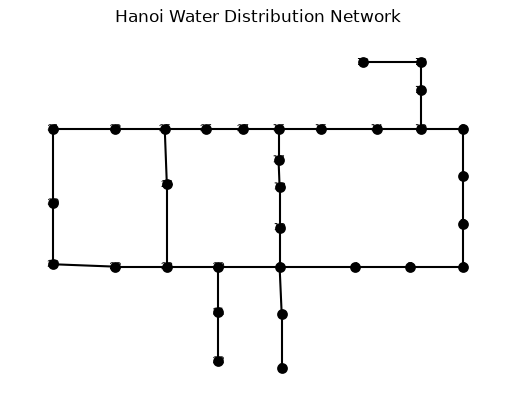

In [30]:
import wntr
import matplotlib.pyplot as plt

inp_path = BASE / "Scenario-1" / "Hanoi_Scenario-1.inp"

wn = wntr.network.WaterNetworkModel(inp_path)

plt.figure(figsize=(12, 10))

wntr.graphics.plot_network(
    wn,
    node_size=60,
    node_labels=True,
    link_width=1.5,
    title="Hanoi Water Distribution Network"
)

plt.show()

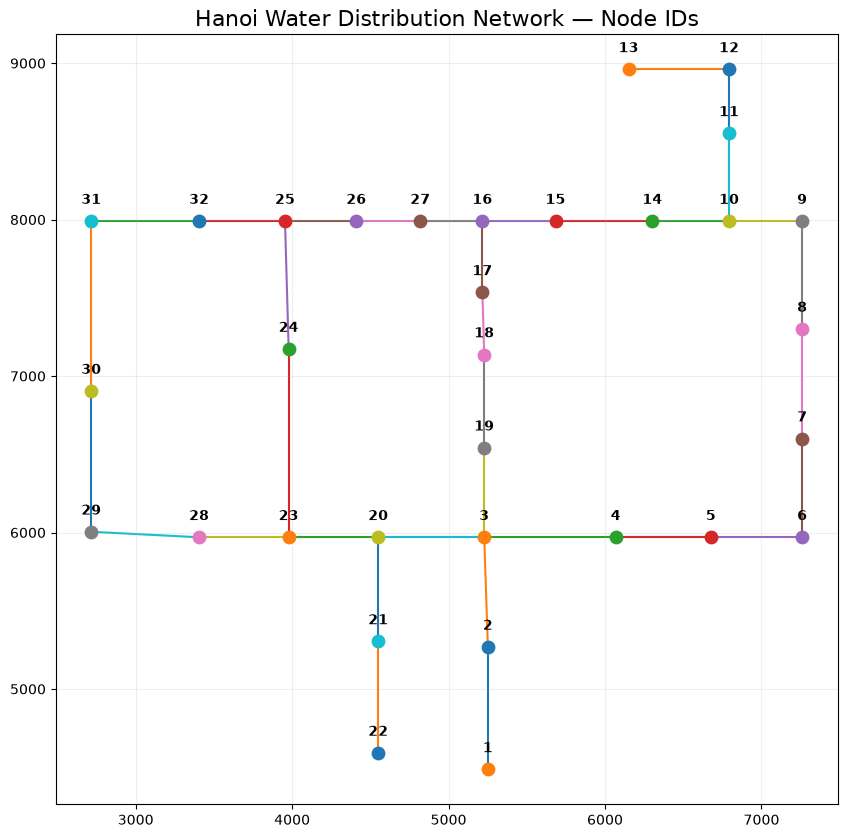

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))

# ---- Draw links manually ----
for link_id in wn.link_name_list:
    link = wn.get_link(link_id)

    start_node = wn.get_node(link.start_node_name)
    end_node = wn.get_node(link.end_node_name)

    x1, y1 = start_node.coordinates
    x2, y2 = end_node.coordinates

    ax.plot([x1, x2], [y1, y2], linewidth=1.5, zorder=1)

# ---- Draw nodes + labels manually ----
for node_id in wn.node_name_list:
    node = wn.get_node(node_id)
    x, y = node.coordinates

    ax.scatter(x, y, s=80, zorder=2)

    ax.annotate(
        str(node_id),
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        zorder=3
    )

ax.set_title("Hanoi Water Distribution Network — Node IDs", fontsize=16)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

plt.show()

In [32]:
node_coords = []

for node_id in wn.node_name_list:
    x, y = wn.get_node(node_id).coordinates
    node_coords.append({
        "Node": node_id,
        "X": x,
        "Y": y
    })

node_coords_df = pd.DataFrame(node_coords)

display(node_coords_df)

,Node,X,Y
0,2,5251.17,5268.69
1,3,5227.80,5969.63
2,4,6068.93,5969.63
3,5,6676.40,5969.63
4,6,7260.51,5969.63
5,7,7260.51,6600.47
6,8,7260.51,7301.40
7,9,7260.51,7990.65
8,10,6793.22,7990.65
9,11,6793.22,8551.40


In [33]:
# ============================================================
# INSPECT NETWORK TOPOLOGY USING WNTR
# ============================================================

topology_rows = []

for link_id in wn.link_name_list:
    link = wn.get_link(link_id)

    topology_rows.append({
        "link_id": str(link_id),
        "start_node": str(link.start_node_name),
        "end_node": str(link.end_node_name),
        "link_type": type(link).__name__
    })

topology_df = pd.DataFrame(topology_rows)

print("NETWORK TOPOLOGY")
print("=" * 70)
print("Number of links:", len(topology_df))

display(topology_df)

# ============================================================
# INSPECT LINK FLOW CSV
# ============================================================

flow_path = BASE / "Scenario-1" / "Link_flows.csv"

flow_sample = pd.read_csv(flow_path, nrows=5)

print("\nLINK FLOW CSV")
print("=" * 70)
print("Shape:", flow_sample.shape)
print("\nColumns:")
print(flow_sample.columns.tolist())

# ============================================================
# CHECK WHETHER LINK IDs MATCH
# ============================================================

flow_link_columns = [
    str(col) for col in flow_sample.columns
    if str(col) != "Unnamed: 0"
]

wntr_links = [str(link_id) for link_id in wn.link_name_list]

print("\nMATCHING CHECK")
print("=" * 70)

print("WNTR links:", len(wntr_links))
print("Flow columns:", len(flow_link_columns))

print("\nLinks in WNTR but not CSV:")
print(sorted(set(wntr_links) - set(flow_link_columns)))

print("\nLinks in CSV but not WNTR:")
print(sorted(set(flow_link_columns) - set(wntr_links)))

print("\nExact order match:")
print(wntr_links == flow_link_columns)

NETWORK TOPOLOGY
Number of links: 34


,link_id,start_node,end_node,link_type
0,1,1,2,Pipe
1,2,2,3,Pipe
2,3,3,4,Pipe
3,4,4,5,Pipe
4,5,5,6,Pipe
5,6,6,7,Pipe
6,7,7,8,Pipe
7,8,8,9,Pipe
8,9,9,10,Pipe
9,10,10,11,Pipe



LINK FLOW CSV
Shape: (5, 35)

Columns:
['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34']

MATCHING CHECK
WNTR links: 34
Flow columns: 34

Links in WNTR but not CSV:
[]

Links in CSV but not WNTR:
[]

Exact order match:
True


In [34]:
# ============================================================
# BUILD CANONICAL NODE / LINK STRUCTURE
# ============================================================

# Fixed node ordering for EVERY sample
CANONICAL_NODES = [str(n) for n in wn.node_name_list]

# For each node, store (link_id, sign)
# sign = -1 if node is the WNTR start node
# sign = +1 if node is the WNTR end node

NODE_LINK_MAP = {node_id: [] for node_id in CANONICAL_NODES}

for link_id in wn.link_name_list:
    link = wn.get_link(link_id)

    start = str(link.start_node_name)
    end = str(link.end_node_name)
    link_id = str(link_id)

    NODE_LINK_MAP[start].append((link_id, -1))
    NODE_LINK_MAP[end].append((link_id, +1))


print("Canonical nodes:", len(CANONICAL_NODES))
print("Canonical links:", len(wn.link_name_list))

print("\nNode → connected links")
for node_id in CANONICAL_NODES:
    print(f"Node {node_id}: {NODE_LINK_MAP[node_id]}")

Canonical nodes: 32
Canonical links: 34

Node → connected links
Node 2: [('1', 1), ('2', -1)]
Node 3: [('2', 1), ('3', -1), ('19', 1), ('20', -1)]
Node 4: [('3', 1), ('4', -1)]
Node 5: [('4', 1), ('5', -1)]
Node 6: [('5', 1), ('6', -1)]
Node 7: [('6', 1), ('7', -1)]
Node 8: [('7', 1), ('8', -1)]
Node 9: [('8', 1), ('9', -1)]
Node 10: [('9', 1), ('10', -1), ('13', -1)]
Node 11: [('10', 1), ('11', -1)]
Node 12: [('11', 1), ('12', -1)]
Node 13: [('12', 1)]
Node 14: [('13', 1), ('14', -1)]
Node 15: [('14', 1), ('15', -1)]
Node 16: [('15', 1), ('16', 1), ('28', -1)]
Node 17: [('16', -1), ('17', -1)]
Node 18: [('17', 1), ('18', -1)]
Node 19: [('18', 1), ('19', -1)]
Node 20: [('20', 1), ('21', -1), ('23', -1)]
Node 21: [('21', 1), ('22', -1)]
Node 22: [('22', 1)]
Node 23: [('23', 1), ('24', -1), ('29', -1)]
Node 24: [('24', 1), ('25', -1)]
Node 25: [('25', 1), ('26', 1), ('34', -1)]
Node 26: [('26', -1), ('27', 1)]
Node 27: [('27', -1), ('28', 1)]
Node 28: [('29', 1), ('30', -1)]
Node 29: [('

In [35]:
# ============================================================
# COMPUTE NODE-WISE CONTINUITY RESIDUALS
# ============================================================
import numpy as np

def compute_residual_vector(flow_row, demand_row):
    """
    Returns a fixed-length residual vector of shape (32,).

    flow_row   : one timestamp from Link_flows.csv
    demand_row : matching timestamp from Node_demands.csv

    Residual at node i:
        r_i = sum(signed connected flows) - demand_i
    """

    residuals = []

    for node_id in CANONICAL_NODES:

        # Net flow entering the node
        net_flow = 0.0

        for link_id, sign in NODE_LINK_MAP[node_id]:
            net_flow += sign * float(flow_row[link_id])

        # IMPORTANT:
        # demand CSV may contain leak_node columns.
        # We only use canonical physical nodes.
        demand = float(demand_row[node_id])

        residual = net_flow - demand

        residuals.append(residual)

    return np.array(residuals, dtype=np.float32)

In [36]:
# ============================================================
# TEST RESIDUALS ON SCENARIO-1 (NO LEAK)
# ============================================================

baseline_flows = pd.read_csv(
    BASE / "Scenario-1" / "Link_flows.csv"
)

baseline_demands = pd.read_csv(
    BASE / "Scenario-1" / "Node_demands.csv"
)

print("Flows shape:", baseline_flows.shape)
print("Demands shape:", baseline_demands.shape)

# Compute residual at first timestamp
r0 = compute_residual_vector(
    baseline_flows.iloc[0],
    baseline_demands.iloc[0]
)

print("\nResidual vector shape:", r0.shape)
print("Residuals:")
print(r0)

print("\nAbsolute residual statistics:")
print("Max :", np.max(np.abs(r0)))
print("Mean:", np.mean(np.abs(r0)))
print("Sum :", np.sum(np.abs(r0)))

Flows shape: (17520, 35)
Demands shape: (17520, 33)

Residual vector shape: (32,)
Residuals:
[ 0.000e+00 -1.000e-05  0.000e+00  0.000e+00 -7.105e-15  0.000e+00  1.066e-14 -3.553e-15 -7.105e-15 -7.105e-15  7.105e-15  0.000e+00 -1.000e-05  1.776e-15  4.441e-16 -7.105e-15  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00 -1.066e-14 -1.000e-05  5.329e-15  0.000e+00  0.000e+00  1.776e-15
  0.000e+00  0.000e+00  0.000e+00 -7.105e-15  0.000e+00]

Absolute residual statistics:
Max : 1e-05
Mean: 9.375e-07
Sum : 3e-05


In [37]:
# ============================================================
# TEST CONTINUITY RESIDUALS ON A LEAKING SCENARIO
# ============================================================

scenario_id = 2

leak_flows = pd.read_csv(
    BASE / f"Scenario-{scenario_id}" / "Link_flows.csv"
)

leak_demands = pd.read_csv(
    BASE / f"Scenario-{scenario_id}" / "Node_demands.csv"
)

print("Flows shape:", leak_flows.shape)
print("Demands shape:", leak_demands.shape)

# Compute residual statistics over a few timestamps
test_indices = [0, 1000, 5000, 10000, 15000]

for t in test_indices:
    r = compute_residual_vector(
        leak_flows.iloc[t],
        leak_demands.iloc[t]
    )

    print(f"\nTimestamp index: {t}")
    print("Max abs residual :", np.max(np.abs(r)))
    print("Mean abs residual:", np.mean(np.abs(r)))

    # Show strongest residual nodes
    strongest = np.argsort(np.abs(r))[::-1][:5]

    print("Top residual nodes:")
    for idx in strongest:
        print(
            f"  Node {CANONICAL_NODES[idx]}: "
            f"{r[idx]:.6f}"
        )

Flows shape: (17520, 37)
Demands shape: (17520, 35)

Timestamp index: 0
Max abs residual : 1e-05
Mean abs residual: 1.875e-06
Top residual nodes:
  Node 26: 0.000010
  Node 25: -0.000010
  Node 24: 0.000010
  Node 10: -0.000010
  Node 6: 0.000010

Timestamp index: 1000
Max abs residual : 1e-05
Mean abs residual: 3.125e-07
Top residual nodes:
  Node 23: 0.000010
  Node 3: 0.000000
  Node 6: 0.000000
  Node 24: 0.000000
  Node 10: -0.000000

Timestamp index: 5000
Max abs residual : 1e-05
Mean abs residual: 1.25e-06
Top residual nodes:
  Node 31: 0.000010
  Node 23: -0.000010
  Node 20: 0.000010
  Node 16: 0.000010
  Node 3: 0.000000

Timestamp index: 10000
Max abs residual : 1e-05
Mean abs residual: 1.875e-06
Top residual nodes:
  Node 20: -0.000010
  Node 18: -0.000010
  Node 23: 0.000010
  Node 10: 0.000010
  Node 8: -0.000010

Timestamp index: 15000
Max abs residual : 2.842171e-14
Mean abs residual: 2.164935e-15
Top residual nodes:
  Node 3: -0.000000
  Node 23: -0.000000
  Node 6: 0.

In [38]:
# ============================================================
# CHECK TEMPORAL ALIGNMENT + PRESSURE DEVIATION
# ============================================================

baseline_pressures = pd.read_csv(
    BASE / "Scenario-1" / "Node_pressures.csv"
)

leak_pressures = pd.read_csv(
    BASE / "Scenario-2" / "Node_pressures.csv"
)

print("Baseline shape:", baseline_pressures.shape)
print("Leak shape:", leak_pressures.shape)

print("\nBaseline timestamps:")
print(baseline_pressures["Unnamed: 0"].head())
print(baseline_pressures["Unnamed: 0"].tail())

print("\nLeak timestamps:")
print(leak_pressures["Unnamed: 0"].head())
print(leak_pressures["Unnamed: 0"].tail())

print("\nTimestamps exactly aligned:")
print(
    baseline_pressures["Unnamed: 0"].equals(
        leak_pressures["Unnamed: 0"]
    )
)

# Canonical physical nodes only
H0 = baseline_pressures[CANONICAL_NODES]
H2 = leak_pressures[CANONICAL_NODES]

delta_H = H2 - H0

print("\nPressure deviation statistics:")
print("Maximum absolute ΔH:", delta_H.abs().to_numpy().max())
print("Mean absolute ΔH:", delta_H.abs().to_numpy().mean())

# Inspect a few times
for t in [0, 1000, 5000, 10000, 15000]:
    dH = delta_H.iloc[t]

    strongest_idx = dH.abs().sort_values(ascending=False).head(5)

    print(f"\nTimestamp {t}:")
    for node_id, value in strongest_idx.items():
        print(f"  Node {node_id}: ΔH = {value:.6f}")

Baseline shape: (17520, 33)
Leak shape: (17520, 35)

Baseline timestamps:
0    2024-01-01 00:00:00
1    2024-01-01 00:30:00
2    2024-01-01 01:00:00
3    2024-01-01 01:30:00
4    2024-01-01 02:00:00
Name: Unnamed: 0, dtype: str
17515    2024-12-30 21:30:00
17516    2024-12-30 22:00:00
17517    2024-12-30 22:30:00
17518    2024-12-30 23:00:00
17519    2024-12-30 23:30:00
Name: Unnamed: 0, dtype: str

Leak timestamps:
0    2024-01-01 00:00:00
1    2024-01-01 00:30:00
2    2024-01-01 01:00:00
3    2024-01-01 01:30:00
4    2024-01-01 02:00:00
Name: Unnamed: 0, dtype: str
17515    2024-12-30 21:30:00
17516    2024-12-30 22:00:00
17517    2024-12-30 22:30:00
17518    2024-12-30 23:00:00
17519    2024-12-30 23:30:00
Name: Unnamed: 0, dtype: str

Timestamps exactly aligned:
True

Pressure deviation statistics:
Maximum absolute ΔH: 39.239079999999994
Mean absolute ΔH: 2.203651191388414

Timestamp 0:
  Node 18: ΔH = 0.308740
  Node 22: ΔH = 0.284750
  Node 21: ΔH = 0.193070
  Node 20: ΔH = 0.113

In [39]:
# Pick one known leak from Scenario-2
scenario_id = 2
leak_id = "leak_node0"

# Get its metadata
leak_info = leak_metadata[
    (leak_metadata["scenario"] == scenario_id) &
    (leak_metadata["leak_id"] == leak_id)
].iloc[0]

print("Leak metadata:")
print(leak_info[[
    "scenario", "leak_id", "x0", "y0",
    "leak_start", "leak_end", "demand_file"
]])

# Load the leak demand time series
leak_demand = pd.read_csv(leak_info["demand_file"])

print("\nLeak demand shape:", leak_demand.shape)
print("\nColumns:")
print(leak_demand.columns.tolist())

print("\nFirst 10 rows:")
display(leak_demand.head(10))

print("\nLast 10 rows:")
display(leak_demand.tail(10))

Leak metadata:
scenario                                                       2
leak_id                                               leak_node0
x0                                                       7260.51
y0                                                   7231.791224
leak_start                                   2024-04-24 23:00:00
leak_end                                     2024-05-05 11:30:00
demand_file    /content/Hanoi/HanoiOK/Scenario-2/Leaks/Leak_l...
Name: 0, dtype: object

Leak demand shape: (17520, 2)

Columns:
['Unnamed: 0', 'leak_node0']

First 10 rows:


,Unnamed: 0,leak_node0
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:30:00,0.0
2,2024-01-01 01:00:00,0.0
3,2024-01-01 01:30:00,0.0
4,2024-01-01 02:00:00,0.0
5,2024-01-01 02:30:00,0.0
6,2024-01-01 03:00:00,0.0
7,2024-01-01 03:30:00,0.0
8,2024-01-01 04:00:00,0.0
9,2024-01-01 04:30:00,0.0



Last 10 rows:


,Unnamed: 0,leak_node0
17510,2024-12-30 19:00:00,0.0
17511,2024-12-30 19:30:00,0.0
17512,2024-12-30 20:00:00,0.0
17513,2024-12-30 20:30:00,0.0
17514,2024-12-30 21:00:00,0.0
17515,2024-12-30 21:30:00,0.0
17516,2024-12-30 22:00:00,0.0
17517,2024-12-30 22:30:00,0.0
17518,2024-12-30 23:00:00,0.0
17519,2024-12-30 23:30:00,0.0


In [43]:
# ============================================================
# INSPECT THE ACTIVE PART OF THE LEAK
# ============================================================

leak_values = leak_demand[leak_id]

active_leak = leak_demand[leak_values != 0]

print("Number of timestamps with an active leak:", len(active_leak))

print("\nFirst active timestamps:")
display(active_leak.head())

print("\nLast active timestamps:")
display(active_leak.tail())

print("\nLeak flow statistics:")
print(active_leak[leak_id].describe())

Number of timestamps with an active leak: 506

First active timestamps:


,Unnamed: 0,leak_node0
5518,2024-04-24 23:00:00,37.87265
5519,2024-04-24 23:30:00,38.74018
5520,2024-04-25 00:00:00,38.68393
5521,2024-04-25 00:30:00,38.85943
5522,2024-04-25 01:00:00,38.81340



Last active timestamps:


,Unnamed: 0,leak_node0
6019,2024-05-05 09:30:00,38.43061
6020,2024-05-05 10:00:00,38.46146
6021,2024-05-05 10:30:00,38.15996
6022,2024-05-05 11:00:00,38.02182
6023,2024-05-05 11:30:00,38.21781



Leak flow statistics:
count    506.000000
mean      38.467930
std        0.342507
min       37.223460
25%       38.250282
50%       38.517170
75%       38.750705
max       39.000050
Name: leak_node0, dtype: float64


In [44]:
# ============================================================
# BUILD GENERIC LEAK TRAINING DATASET
# ============================================================

X_samples = []
Y_samples = []

skipped_scenarios = []
processed_leaks = 0

# Baseline pressures: Scenario-1
baseline_pressures = pd.read_csv(
    BASE / "Scenario-1" / "Node_pressures.csv"
)

baseline_times = baseline_pressures["Unnamed: 0"]
H0 = baseline_pressures[CANONICAL_NODES].to_numpy(
    dtype=np.float32
)

for scenario_id in sorted(leak_metadata["scenario"].unique()):

    scenario_path = BASE / f"Scenario-{scenario_id}"

    pressure_path = scenario_path / "Node_pressures.csv"

    if not pressure_path.exists():
        skipped_scenarios.append(
            (scenario_id, "missing pressure file")
        )
        continue

    # Load scenario pressures
    scenario_pressures = pd.read_csv(pressure_path)

    # Check timestamp alignment with baseline
    if not scenario_pressures["Unnamed: 0"].equals(baseline_times):
        skipped_scenarios.append(
            (scenario_id, "timestamp mismatch")
        )
        continue

    # Pressure deviation for all timestamps
    H = scenario_pressures[CANONICAL_NODES].to_numpy(
        dtype=np.float32
    )

    delta_H = H - H0

    # Get every leak belonging to this scenario
    scenario_leaks = leak_metadata[
        leak_metadata["scenario"] == scenario_id
    ]

    for _, leak_info in scenario_leaks.iterrows():

        leak_id = leak_info["leak_id"]
        demand_path = leak_info["demand_file"]

        if not Path(demand_path).exists():
            print(
                f"WARNING: Missing demand file "
                f"for Scenario {scenario_id}, {leak_id}"
            )
            continue

        # Load leak flow time series
        leak_demand = pd.read_csv(demand_path)

        # Verify temporal alignment
        if not leak_demand["Unnamed: 0"].equals(baseline_times):
            print(
                f"WARNING: Timestamp mismatch "
                f"for Scenario {scenario_id}, {leak_id}"
            )
            continue

        # Extract leak flow
        QL = leak_demand[leak_id].to_numpy(
            dtype=np.float32
        )

        # Only keep timestamps where THIS leak is active
        active_indices = np.where(QL != 0)[0]

        for t in active_indices:

            # Input:
            # 32 pressure deviations
            X_samples.append(delta_H[t])

            # Target:
            # [leak x, leak y, leak flow]
            Y_samples.append([
                float(leak_info["x0"]),
                float(leak_info["y0"]),
                float(QL[t])
            ])

        processed_leaks += 1

X = np.asarray(X_samples, dtype=np.float32)
Y = np.asarray(Y_samples, dtype=np.float32)

print("=" * 60)
print("GENERIC DATASET BUILD COMPLETE")
print("=" * 60)

print("Processed leaks:", processed_leaks)
print("Skipped scenarios:", len(skipped_scenarios))
print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nInput per sample:")
print("32-dimensional ΔH vector")

print("\nTarget per sample:")
print("[leak_x, leak_y, leak_flow]")

print("\nFirst sample:")
print("X:", X[0])
print("Y:", Y[0])

GENERIC DATASET BUILD COMPLETE
Processed leaks: 754
Skipped scenarios: 0
X shape: (3371652, 32)
Y shape: (3371652, 3)

Input per sample:
32-dimensional ΔH vector

Target per sample:
[leak_x, leak_y, leak_flow]

First sample:
X: [-0.224 -1.863 -1.907 -2.039 -2.049 -2.099 -2.175 -2.226 -2.284 -2.35  -2.386 -2.612 -2.566 -2.595 -2.782 -3.464 -2.666 -2.061 -2.03  -2.156 -1.743 -2.157 -2.214 -2.287 -2.515 -2.633 -2.17  -2.065 -2.328 -2.319 -2.292  0.   ]
Y: [7260.51  7231.791   37.873]


In [45]:
# ============================================================
# VERIFY THE FINAL TRAINING DATASET
# ============================================================

print("=" * 60)
print("FINAL DATASET CHECK")
print("=" * 60)

print("\nX shape:", X.shape)
print("Y shape:", Y.shape)

print("\nExpected:")
print("X → [number of samples, 32 pressure deviations]")
print("Y → [number of samples, 3 leak properties]")

print("\nAny NaNs?")
print("X:", np.isnan(X).any())
print("Y:", np.isnan(Y).any())

print("\nAny infinities?")
print("X:", np.isinf(X).any())
print("Y:", np.isinf(Y).any())

print("\nPressure deviation range:")
print("Min:", X.min())
print("Max:", X.max())
print("Mean:", X.mean())

print("\nLeak target ranges:")
print("X-coordinate:", Y[:, 0].min(), "to", Y[:, 0].max())
print("Y-coordinate:", Y[:, 1].min(), "to", Y[:, 1].max())
print("Leak flow   :", Y[:, 2].min(), "to", Y[:, 2].max())

print("\nFirst 3 samples:")
for i in range(3):
    print(f"\nSample {i}")
    print("Pressure pattern ΔH:", X[i])
    print("Leak target [x, y, Q]:", Y[i])

FINAL DATASET CHECK

X shape: (3371652, 32)
Y shape: (3371652, 3)

Expected:
X → [number of samples, 32 pressure deviations]
Y → [number of samples, 3 leak properties]

Any NaNs?
X: False
Y: False

Any infinities?
X: False
Y: False

Pressure deviation range:
Min: -68.91452
Max: 10.35508
Mean: -8.169906

Leak target ranges:
X-coordinate: 2716.12 to 7260.51
Y-coordinate: 4630.26 to 8960.28
Leak flow   : 3.8827 to 9139.457

First 3 samples:

Sample 0
Pressure pattern ΔH: [-0.224 -1.863 -1.907 -2.039 -2.049 -2.099 -2.175 -2.226 -2.284 -2.35  -2.386 -2.612 -2.566 -2.595 -2.782 -3.464 -2.666 -2.061 -2.03  -2.156 -1.743 -2.157 -2.214 -2.287 -2.515 -2.633 -2.17  -2.065 -2.328 -2.319 -2.292  0.   ]
Leak target [x, y, Q]: [7260.51  7231.791   37.873]

Sample 1
Pressure pattern ΔH: [-0.041  0.015  0.009 -0.011 -0.004 -0.016 -0.043 -0.036 -0.05  -0.035 -0.002  0.154 -0.145 -0.226 -0.288  0.21   0.314  0.133  0.035  0.567  0.949 -0.09  -0.217 -0.295 -0.493 -0.469 -0.364 -0.355 -0.266 -0.262 -0.263 

In [46]:
# ============================================================
# TRAIN / VALIDATION SPLIT + NORMALIZATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split indices first
indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

# Create splits
X_train = X[train_idx]
X_val = X[val_idx]

Y_train = Y[train_idx]
Y_val = Y[val_idx]

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))

# Normalize inputs
X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_val_scaled = X_scaler.transform(X_val)

# Normalize targets
Y_scaler = StandardScaler()

Y_train_scaled = Y_scaler.fit_transform(Y_train)
Y_val_scaled = Y_scaler.transform(Y_val)

# Convert to float32
X_train_scaled = X_train_scaled.astype(np.float32)
X_val_scaled = X_val_scaled.astype(np.float32)

Y_train_scaled = Y_train_scaled.astype(np.float32)
Y_val_scaled = Y_val_scaled.astype(np.float32)

print("\nAfter normalization:")
print("X train mean:", X_train_scaled.mean())
print("X train std :", X_train_scaled.std())

print("\nY train mean per target:", Y_train_scaled.mean(axis=0))
print("Y train std per target :", Y_train_scaled.std(axis=0))

Train samples: 2697321
Validation samples: 674331

After normalization:
X train mean: -1.6841999e-09
X train std : 0.98425066

Y train mean per target: [-1.637e-06  1.343e-06 -9.299e-09]
Y train std per target : [1.    0.997 0.999]
